In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import math
from scipy.stats import pearsonr

parquet file comes from notebook 07

In [2]:
# load merged environmental + embeddings data
# environmental also contains supervised cls label and geometric features
load_dir = '/home/jko/ssl-cpi-analysis/data'
load_filename = 'cls_env_all_merged.parquet'
load_path = os.path.join(load_dir, load_filename)
df = pd.read_parquet(load_path)
df.shape

(524033, 432)

In [3]:
# define useful colnames lists
emb_cols = [str(i) for i in range(384)]
env_cols = ['Latitude [degrees]', 'Longitude [degrees]', 'Altitude [m]', 'Pressure [hPa]', 'Temperature [C]', 'Ice Water Content [g/m3]', 'PSD IWC [g/m3]']
geo_feature_cols = ['Aspect Ratio', 'Extreme Points', 'Contour Area [pixels]', 'Perimeter [pixels]', 'Area Ratio', 'Complexity', 'Circularity', 'Roundness', 'Perimeter-Area Ratio', 'Solidity', 'Equivalent Diameter', 'Blur'] # note: aspect_ratio_elip is not in this data

# Distributions of environmental variables

In [ ]:
# Plot distributions of environmental variables 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_column_distributions(df, bins=30, figsize_per_plot=(4, 3)):
    # Number of columns to plot
    num_cols = df.shape[1]

    # Compute best grid size: square-like layout
    n_cols = math.ceil(math.sqrt(num_cols))
    n_rows = math.ceil(num_cols / n_cols)

    # Create figure with appropriate size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(df.columns):
        ax = axes[idx]
        if pd.api.types.is_numeric_dtype(df[col]):
            ax.hist(df[col].dropna(), bins=bins, color='gray', edgecolor='black')
            ax.set_title(col)
        else:
            ax.axis('off')  # Skip non-numeric columns

    # Turn off any unused subplots
    for j in range(num_cols, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Example DataFrame
plot_column_distributions(df[env_cols])

In [ ]:
# Plot correlation between 'Ice Water Content [g/m3]'vs' PSD IWC [g/m3]'
x_col = 'PSD IWC [g/m3]'
y_col = 'Ice Water Content [g/m3]'

# Drop rows with NaNs
data = df[[x_col, y_col]].dropna()

# Compute Pearson correlation
r, p = pearsonr(data[x_col], data[y_col])

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(data=data, x=x_col, y=y_col, s=10, edgecolor='black', alpha=0.7)

# Annotate correlation
plt.title(f"Scatter Plot with Correlation (r = {r:.2f}, p = {p:.2e})")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Density plot version 
x_col = 'PSD IWC [g/m3]'
y_col = 'Ice Water Content [g/m3]'

# Drop NaNs
data = df[[x_col, y_col]].dropna().sample(1000)

# Compute correlation
r, p = pearsonr(data[x_col], data[y_col])

# Plot
plt.figure(figsize=(3, 3))
sns.kdeplot(
    data=data, x=x_col, y=y_col,
    fill=True, cmap="mako", thresh=0.05, levels=100
)

# Optionally overlay scatter
sns.scatterplot(data=data, x=x_col, y=y_col, s=10, color='black', alpha=0.3)

# Annotate
plt.title(f"2D Density Plot (r = {r:.2f}, p = {p:.2e})")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)
plt.tight_layout()
plt.show()

# Computing L2 norm of embeddings

In [ ]:
# Check the distribution of embeddings L2 norms
df_embeddings = df[emb_cols]

# Step 1: Compute L2 norm for each row
l2_norms = np.linalg.norm(df_embeddings.values, axis=1)

# Step 2: Plot the distribution
sns.histplot(l2_norms, bins=50, kde=True)
plt.xlabel("L2 Norm")
plt.ylabel("Frequency")
plt.title("Distribution of L2 Norms of Embeddings")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate unit normalized embeddings
# Convert to numpy array
embeddings = df_embeddings.values

# Compute L2 norms for each row (sample)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)

# Avoid division by zero
norms[norms == 0] = 1

# Normalize each row to unit norm
embeddings_normalized = embeddings / norms

# If you want back a DataFrame with the same columns and index:
df_embeddings_normalized = pd.DataFrame(embeddings_normalized, columns=df_embeddings.columns, index=df_embeddings.index)

l2_norms = np.linalg.norm(df_embeddings_normalized.values, axis=1)

# print statistics of new l2 norms
mean_val = np.mean(l2_norms)
median_val = np.median(l2_norms)
std_val = np.std(l2_norms)
min_val = np.min(l2_norms)
max_val = np.max(l2_norms)

print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Standard Deviation: {std_val}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")

# Cosine Similarity Analysis

In [ ]:
# Mean Resultant Length sample
# Suppose embeddings is an (N, D) array of N normalized D-dimensional vectors
# Example: generate 100 random 3D unit vectors
n_subset = 100
subset = df_embeddings_normalized.sample(n_subset)

# Calculate the mean vector
mean_vector = subset.mean(axis=0).values 

# Calculate the mean resultant length (MRL)
mean_resultant_length = np.linalg.norm(mean_vector)

print("Mean resultant length:", mean_resultant_length)

In [ ]:
# Calculate MRL as a function of temperature
norm_emb_temp = pd.concat([df_embeddings_normalized, df['Temperature [C]']], axis=1)
norm_emb_temp.head()

In [ ]:
# 1. Bin by temperature
bins = np.arange(-70, 10, 10)  # [-70, -60, ..., 0]
labels = bins[:-1] + 5         # Midpoints: [-65, -55, ..., -5]
df['temp_bin'] = pd.cut(df['Temperature [C]'], bins=bins, labels=labels)

# 2. Calculate mean resultant length and count for each bin
mrls = []
midpoints = []
counts = []
for bin_label in labels:
    bin_df = df[df['temp_bin'] == bin_label]
    count = len(bin_df)
    counts.append(count)
    print(f"Temperature bin {bin_label}: {count} samples")
    if count == 0:
        mrls.append(np.nan)
        midpoints.append(bin_label)
        continue
    # Normalize embeddings if not already normalized
    emb = bin_df[emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    mean_vec = emb_norm.mean(axis=0)
    mrl = np.linalg.norm(mean_vec)
    mrls.append(mrl)
    midpoints.append(bin_label)

# 3. Plot with counts above each point
plt.figure(figsize=(7,4))
plt.plot(midpoints, mrls, marker='o')
for x, y, count in zip(midpoints, mrls, counts):
    if not np.isnan(y):
        plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Temperature (°C)')
plt.ylabel('Mean Resultant Length')
plt.title('Mean Resultant Length vs. Temperature\n'
          r'$\mathregular{MRL=1:}$ no diversity, $\mathregular{MRL=0:}$ maximum diversity',
          fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Cosine similarity
# 1. Bin by temperature
bins = np.arange(-70, 10, 10)  # [-70, -60, ..., 0]
labels = bins[:-1] + 5         # Midpoints: [-65, -55, ..., -5]
df['temp_bin'] = pd.cut(df['Temperature [C]'], bins=bins, labels=labels)

# 2. Calculate mean cosine similarity and count for each bin
cos_sims = []
midpoints = []
counts = []
for bin_label in labels:
    bin_df = df[df['temp_bin'] == bin_label]
    count = len(bin_df)
    counts.append(count)
    print(f"Temperature bin {bin_label}: {count} samples")
    if count == 0:
        cos_sims.append(np.nan)
        midpoints.append(bin_label)
        continue
    # Normalize embeddings if not already normalized
    emb = bin_df[emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    mean_vec = emb_norm.mean(axis=0)
    mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
    # Cosine similarity of each embedding to the mean vector
    cos_sim = np.dot(emb_norm, mean_vec_norm)
    mean_cos_sim = np.mean(cos_sim)
    cos_sims.append(mean_cos_sim)
    midpoints.append(bin_label)

# 3. Plot with counts above each point
plt.figure(figsize=(7,4))
plt.plot(midpoints, cos_sims, marker='o')
for x, y, count in zip(midpoints, cos_sims, counts):
    if not np.isnan(y):
        plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Temperature (°C)')
plt.ylabel('Mean Cosine Similarity to Bin Mean')
plt.title('Mean Cosine Similarity vs. Temperature\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Note: cosine similarity and mean resultant length area EQUIVALENT if vectors are normalized!!!

In [ ]:
# Cosine similarity by pressure
# 1. Bin by pressure
bins = np.arange(150, 600, 50)  # [150, 170, ..., 610]
labels = bins[:-1] + 10         # Midpoints: [160, 180, ..., 610]
df['pressure_bin'] = pd.cut(df['Pressure [hPa]'], bins=bins, labels=labels)

# 2. Calculate mean cosine similarity and count for each bin
cos_sims = []
midpoints = []
counts = []
for bin_label in labels:
    bin_df = df[df['pressure_bin'] == bin_label]
    count = len(bin_df)
    counts.append(count)
    print(f"Pressure bin {bin_label}: {count} samples")
    if count == 0:
        cos_sims.append(np.nan)
        midpoints.append(bin_label)
        continue
    # Normalize embeddings if not already normalized
    emb = bin_df[emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    mean_vec = emb_norm.mean(axis=0)
    mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
    # Cosine similarity of each embedding to the mean vector
    cos_sim = np.dot(emb_norm, mean_vec_norm)
    mean_cos_sim = np.mean(cos_sim)
    cos_sims.append(mean_cos_sim)
    midpoints.append(bin_label)

# 3. Plot with counts above each point
plt.figure(figsize=(8,4))
plt.plot(midpoints, cos_sims, marker='o')
for x, y, count in zip(midpoints, cos_sims, counts):
    if not np.isnan(y):
        plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Pressure (hPa)')
plt.ylabel('Mean Cosine Similarity to Bin Mean')
plt.title('Mean Cosine Similarity vs. Pressure\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Now as a function of temperature and pressure
# Assume df has columns: 'Temperature [C]', 'Pressure [hPa]', and embedding columns in emb_cols

# 1. Bin temperature and pressure
temp_bins = np.arange(-70, 10, 10)
temp_labels = temp_bins[:-1] + 5
df['temp_bin'] = pd.cut(df['Temperature [C]'], bins=temp_bins, labels=temp_labels)

pres_bins = np.arange(150, 620, 20)
pres_labels = pres_bins[:-1] + 10
df['pres_bin'] = pd.cut(df['Pressure [hPa]'], bins=pres_bins, labels=pres_labels)

# 2. Calculate mean cosine similarity for each (temp_bin, pres_bin)
results = []
for t in temp_labels:
    for p in pres_labels:
        bin_df = df[(df['temp_bin'] == t) & (df['pres_bin'] == p)]
        count = len(bin_df)
        if count == 0:
            continue
        emb = bin_df[emb_cols].values
        emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        mean_vec = emb_norm.mean(axis=0)
        mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
        cos_sim = np.dot(emb_norm, mean_vec_norm)
        mean_cos_sim = np.mean(cos_sim)
        results.append({'temp': float(t), 'pres': float(p), 'cos_sim': mean_cos_sim, 'count': count})

# 3. Convert results to DataFrame for plotting
results_df = pd.DataFrame(results)

# After you have results_df with a 'cos_sim' column:
vmin = results_df['cos_sim'].min()
vmax = results_df['cos_sim'].max()

plt.figure(figsize=(8,5))
sc = plt.scatter(
    results_df['temp'], results_df['pres'], c=results_df['cos_sim'],
    s=results_df['count']/50,  # or adjust as needed
    cmap='viridis', vmin=vmin, vmax=vmax
)
plt.colorbar(sc, label='Mean Cosine Similarity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (hPa)')
plt.title('Mean Cosine Similarity vs. Temperature and Pressure')
plt.tight_layout()
plt.show()

Explore differences between campaigns

In [ ]:
df.Campaign.unique()

In [ ]:
columns_to_plot = [
    'Latitude [degrees]', 'Longitude [degrees]', 'Altitude [m]',
    'Pressure [hPa]', 'Temperature [C]', 'Ice Water Content [g/m3]', 'PSD IWC [g/m3]'
]

campaigns = df['Campaign'].unique()

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, col in enumerate(columns_to_plot):
        axes[i].hist(df_camp[col].dropna(), bins=30, color='gray', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    # Hide any unused subplot (since 2x4=8 and you have 7 variables)
    for j in range(len(columns_to_plot), len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'Distributions for Campaign: {campaign}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
# Diversity of crystals as a function of campaign 
bins = np.arange(-70, 10, 10)  # [-70, -60, ..., 0]
labels = bins[:-1] + 5         # Midpoints: [-65, -55, ..., -5]
df['temp_bin'] = pd.cut(df['Temperature [C]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6,3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    cos_sims = []
    counts = []
    for bin_label in labels:
        bin_df = df_camp[df_camp['temp_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)
        if count == 0:
            cos_sims.append(np.nan)
            continue
        emb = bin_df[emb_cols].values
        emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        mean_vec = emb_norm.mean(axis=0)
        mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
        cos_sim = np.dot(emb_norm, mean_vec_norm)
        mean_cos_sim = np.mean(cos_sim)
        cos_sims.append(mean_cos_sim)
    plt.plot(labels, cos_sims, marker='o', label=campaign)
    # # Optionally, show counts above points for each campaign
    # for x, y, count in zip(labels, cos_sims, counts):
    #     if not np.isnan(y):
    #         plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=8, color='gray')

plt.xlabel('Temperature (°C)')
plt.ylabel('Mean Cosine Similarity')
plt.title('Mean Cosine Similarity vs. Temperature\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Diversity as function of IWC
# 1. Bin by Ice Water Content (choose appropriate bin edges for your data)
iwc_min = df['Ice Water Content [g/m3]'].min()
iwc_max = df['Ice Water Content [g/m3]'].max()
bins = np.linspace(iwc_min, iwc_max, 11)  # 10 bins, adjust as needed
labels = 0.5 * (bins[:-1] + bins[1:])     # Bin midpoints
df['iwc_bin'] = pd.cut(df['Ice Water Content [g/m3]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6,3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    cos_sims = []
    counts = []
    for bin_label in labels:
        bin_df = df_camp[df_camp['iwc_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)
        if count == 0:
            cos_sims.append(np.nan)
            continue
        emb = bin_df[emb_cols].values
        emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        mean_vec = emb_norm.mean(axis=0)
        mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
        cos_sim = np.dot(emb_norm, mean_vec_norm)
        mean_cos_sim = np.mean(cos_sim)
        cos_sims.append(mean_cos_sim)
    plt.plot(labels, cos_sims, marker='o', label=campaign)
    # Optionally, show counts above points for each campaign
    # for x, y, count in zip(labels, cos_sims, counts):
    #     if not np.isnan(y):
    #         plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=8, color='gray')

plt.xlabel('Ice Water Content [g/m3]')
plt.ylabel('Mean Cosine Similarity')
plt.title('Mean Cosine Similarity vs. Ice Water Content\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Bin by Altitude (choose appropriate bin edges for your data)
alt_min = df['Altitude [m]'].min()
alt_max = df['Altitude [m]'].max()
bins = np.linspace(alt_min, alt_max, 11)  # 10 bins, adjust as needed
labels = 0.5 * (bins[:-1] + bins[1:])     # Bin midpoints
df['alt_bin'] = pd.cut(df['Altitude [m]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6,3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    cos_sims = []
    counts = []
    for bin_label in labels:
        bin_df = df_camp[df_camp['alt_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)
        if count == 0:
            cos_sims.append(np.nan)
            continue
        emb = bin_df[emb_cols].values
        emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        mean_vec = emb_norm.mean(axis=0)
        mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
        cos_sim = np.dot(emb_norm, mean_vec_norm)
        mean_cos_sim = np.mean(cos_sim)
        cos_sims.append(mean_cos_sim)
    plt.plot(labels, cos_sims, marker='o', label=campaign)
    # Optionally, show counts above points for each campaign
    # for x, y, count in zip(labels, cos_sims, counts):
    #     if not np.isnan(y):
    #         plt.text(x, y + 0.02, f'N={count}', ha='center', va='bottom', fontsize=8, color='gray')

plt.xlabel('Altitude [m]')
plt.ylabel('Mean Cosine Similarity')
plt.title('Mean Cosine Similarity vs. Altitude\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Plot the mean diversity (cosine similarity) by campaign
campaigns = df['Campaign'].unique()
cos_sims = []

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    if len(df_camp) == 0:
        cos_sims.append(np.nan)
        continue
    emb = df_camp[emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    mean_vec = emb_norm.mean(axis=0)
    mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
    cos_sim = np.dot(emb_norm, mean_vec_norm)
    mean_cos_sim = np.mean(cos_sim)
    cos_sims.append(mean_cos_sim)

# Create a summary DataFrame
summary_df = pd.DataFrame({'Campaign': campaigns, 'Mean Cosine Similarity': cos_sims})
# plot barplot
plt.figure(figsize=(6,4))
sns.barplot(
    data=summary_df,
    y='Campaign',
    x='Mean Cosine Similarity',
    hue='Campaign',
    palette='tab10',
    orient='h',
    legend=False
)
plt.xlabel('Mean Cosine Similarity')
plt.ylabel('Campaign')
plt.title('Mean Cosine Similarity vs. Altitude\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Intra-habit diversity

In [ ]:
classifications = df['Classification'].unique()
cos_sims = []

for classification in classifications:
    df_class = df[df['Classification'] == classification]
    if len(df_class) == 0:
        cos_sims.append(np.nan)
        continue
    emb = df_class[emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    mean_vec = emb_norm.mean(axis=0)
    mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
    cos_sim = np.dot(emb_norm, mean_vec_norm)
    mean_cos_sim = np.mean(cos_sim)
    cos_sims.append(mean_cos_sim)

# Create a summary DataFrame
summary_df = pd.DataFrame({'Classification': classifications, 'Mean Cosine Similarity': cos_sims})

# Plot barplot
plt.figure(figsize=(6,4))
sns.barplot(
    data=summary_df,
    y='Classification',
    x='Mean Cosine Similarity',
    hue='Classification',
    palette='tab10',
    orient='h',
    legend=False
)
plt.xlabel('Mean Cosine Similarity')
plt.ylabel('Classification')
plt.title('Mean Cosine Similarity by Classification\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

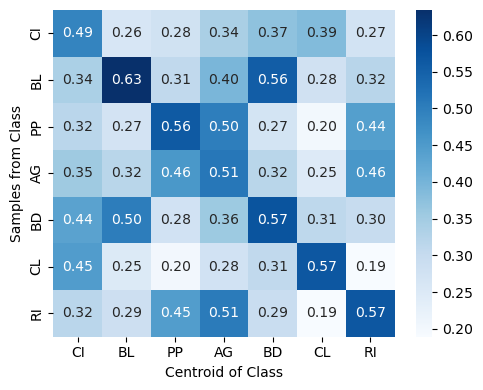

In [9]:
# Inter-class similarity

# Assume df has columns: 'Classification' and embedding columns in emb_cols
classes = df['Classification'].unique()
centroids = {}
# Create concise custom labels
labels_short = ['CI', 'BL', 'PP', 'AG', 'BD', 'CL', 'RI']

# 1. Compute centroids for each class
for cls in classes:
    emb = df[df['Classification'] == cls][emb_cols].values
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    centroid = emb_norm.mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    centroids[cls] = centroid

# 2. Compute pairwise mean cosine similarity
similarity_matrix = np.zeros((len(classes), len(classes)))

for i, class_a in enumerate(classes):
    emb_a = df[df['Classification'] == class_a][emb_cols].values
    emb_a_norm = emb_a / np.linalg.norm(emb_a, axis=1, keepdims=True)
    for j, class_b in enumerate(classes):
        centroid_b = centroids[class_b]
        cos_sims = np.dot(emb_a_norm, centroid_b)
        similarity_matrix[i, j] = np.mean(cos_sims)

# 3. Visualize as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", xticklabels=labels_short, yticklabels=labels_short, cmap="Blues")
plt.xlabel("Centroid of Class")
plt.ylabel("Samples from Class")
# plt.title("Mean Cosine Similarity: Samples vs. Other Class Centroids")
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs'
savepath = os.path.join(savedir, 'inter_class_similarity.png')
plt.savefig(savepath, dpi=300, bbox_inches="tight") # save
plt.show()

Diversity by crystal size

In [ ]:
# 1. Bin by Particle Width (choose appropriate bin edges for your data)
width_min = df['Particle Width [micrometers]'].min()
width_max = df['Particle Width [micrometers]'].max()
bins = np.linspace(width_min, width_max, 11)  # 10 bins, adjust as needed
labels = 0.5 * (bins[:-1] + bins[1:])         # Bin midpoints
df['width_bin'] = pd.cut(df['Particle Width [micrometers]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6,3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    cos_sims = []
    counts = []
    for bin_label in labels:
        bin_df = df_camp[df_camp['width_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)
        if count == 0:
            cos_sims.append(np.nan)
            continue
        emb = bin_df[emb_cols].values
        emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        mean_vec = emb_norm.mean(axis=0)
        mean_vec_norm = mean_vec / np.linalg.norm(mean_vec)
        cos_sim = np.dot(emb_norm, mean_vec_norm)
        mean_cos_sim = np.mean(cos_sim)
        cos_sims.append(mean_cos_sim)
    plt.plot(labels, cos_sims, marker='o', label=campaign)

plt.xlabel('Particle Width [micrometers]')
plt.ylabel('Mean Cosine Similarity')
plt.title('Mean Cosine Similarity vs. Particle Width\n'
          r'$\mathregular{Cosine=1:}$ no diversity, $\mathregular{Cosine=0:}$ maximum diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

# Kappa metric analysis

κ is the "concentration" parameter, describing the spread of a vMF distribution.   
$$
A_p(\kappa) = \left\| \frac{\sum_i^N x_i}{N} \right\| = \bar{R}.
$$

A simple approximation to $\kappa$ is (Sra, 2011)  
$$
\hat{\kappa} = \frac{\bar{R}(p - \bar{R}^2)}{1 - \bar{R}^2},
$$


In [4]:
def estimate_kappa(x: np.ndarray, p: int = None) -> float:
    """
    Estimate kappa (κ) for the von Mises–Fisher distribution using Sra (2011) approximation.

    Parameters:
    -----------
    x : np.ndarray
        An (N, p) array of N embedding vectors (each of dimension p).
    p : int, optional
        Dimensionality of the embedding space. If None, inferred from x.

    Returns:
    --------
    float
        Estimated value of κ (kappa).
    """
    if x.ndim != 2:
        raise ValueError("Input x must be a 2D array of shape (N, p)")
        
    N, inferred_p = x.shape
    if p is None:
        p = inferred_p
    elif p != inferred_p:
        raise ValueError("Provided p does not match dimensionality of x")

    # Normalize vectors to lie on unit hypersphere
    x_normed = x / np.linalg.norm(x, axis=1, keepdims=True)

    # Compute mean resultant vector
    R_bar = np.linalg.norm(np.mean(x_normed, axis=0))

    # Use Sra (2011) approximation for kappa
    kappa_hat = (R_bar * (p - R_bar**2)) / (1 - R_bar**2 + 1e-8)  # add small eps to avoid div by zero

    return kappa_hat

## kappa vs. temperature

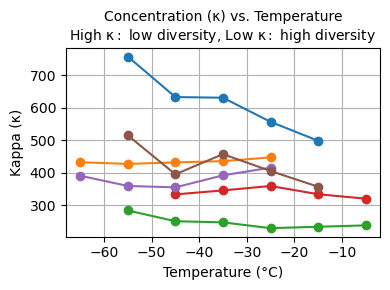

In [6]:
# Diversity of crystals as a function of campaign using κ (kappa)
bins = np.arange(-70, 10, 10)  # Temperature bins: [-70, -60, ..., 0]
labels = bins[:-1] + 5         # Midpoints: [-65, -55, ..., -5]
df['temp_bin'] = pd.cut(df['Temperature [C]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(4,3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    kappas = []
    counts = []
    
    for bin_label in labels:
        bin_df = df_camp[df_camp['temp_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)

        if count == 0:
            kappas.append(np.nan)
            continue

        emb = bin_df[emb_cols].values
        kappa = estimate_kappa(emb)
        kappas.append(kappa)

    plt.plot(labels, kappas, marker='o', label=campaign)

plt.xlabel('Temperature (°C)')
plt.ylabel('Kappa (κ)')
plt.title('Concentration (κ) vs. Temperature\n'
          r'$\mathregular{High\ \kappa:}$ low diversity, $\mathregular{Low\ \kappa:}$ high diversity',
          fontsize=10)
# plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs'
savepath = os.path.join(savedir, 'kappa-temp-by-campaign-v3.pdf')
plt.savefig(savepath, bbox_inches="tight") # save
plt.show()

## kappa vs. size


Campaign: ARM
Bin midpoint (μm) | Count
55.0               892
144.6               3997
234.1               3870
323.6               2395
413.2               1433
502.7               653
592.2               313
681.7               161
771.3               61
860.8               33

Campaign: CRYSTAL_FACE_NASA
Bin midpoint (μm) | Count
55.0               18118
144.6               20629
234.1               6164
323.6               1702
413.2               417
502.7               135
592.2               37
681.7               11
771.3               4
860.8               2

Campaign: CRYSTAL_FACE_UND
Bin midpoint (μm) | Count
55.0               48902
144.6               98406
234.1               57685
323.6               28020
413.2               14488
502.7               7751
592.2               4386
681.7               2545
771.3               1374
860.8               835

Campaign: MC3E
Bin midpoint (μm) | Count
55.0               5655
144.6               37664
234.1               33693

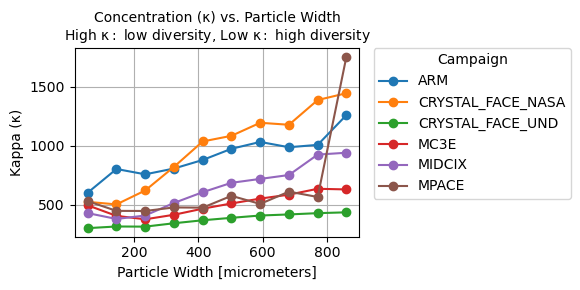

In [14]:
# Diversity of crystals as a function of Particle Width using κ (kappa)
width_min = df['Particle Width [micrometers]'].min()
width_max = df['Particle Width [micrometers]'].max()
bins = np.linspace(width_min, width_max, 11)  # 10 bins (adjust as needed)
labels = 0.5 * (bins[:-1] + bins[1:])         # Midpoints of bins
df['width_bin'] = pd.cut(df['Particle Width [micrometers]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6, 3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    kappas = []
    counts = []
    print(f"\nCampaign: {campaign}")
    print("Bin midpoint (μm) | Count")
    for bin_label in labels:
        bin_df = df_camp[df_camp['width_bin'] == bin_label]
        count = len(bin_df)
        counts.append(count)
        # Print bin midpoint and count
        print(f"{bin_label:.1f}               {count}")

        if count == 0:
            kappas.append(np.nan)
            continue

        emb = bin_df[emb_cols].values
        kappa = estimate_kappa(emb)
        kappas.append(kappa)

    plt.plot(labels, kappas, marker='o', label=campaign)

plt.xlabel('Particle Width [micrometers]')
plt.ylabel('Kappa (κ)')
plt.title('Concentration (κ) vs. Particle Width\n'
          r'$\mathregular{High\ \kappa:}$ low diversity, $\mathregular{Low\ \kappa:}$ high diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


Campaign: ARM
Bin midpoint (μm) | Count
55.0               892
144.6               3997
234.1               3870
323.6               2395
413.2               1433
502.7               653
592.2               313
681.7               161
816.0               94

Campaign: CRYSTAL_FACE_NASA
Bin midpoint (μm) | Count
55.0               18118
144.6               20629
234.1               6164
323.6               1702
413.2               417
502.7               135
592.2               37
681.7               11
816.0               6

Campaign: CRYSTAL_FACE_UND
Bin midpoint (μm) | Count
55.0               48902
144.6               98406
234.1               57685
323.6               28020
413.2               14488
502.7               7751
592.2               4386
681.7               2545
816.0               2209

Campaign: MC3E
Bin midpoint (μm) | Count
55.0               5655
144.6               37664
234.1               33693
323.6               17759
413.2               8652
502.7            

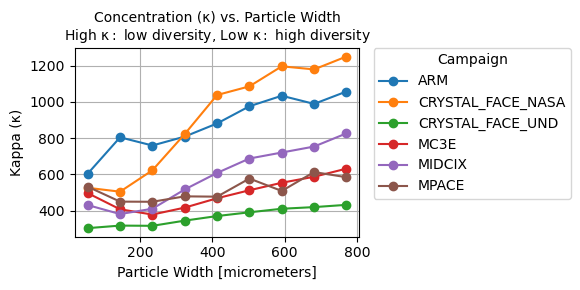

In [9]:
# Diversity of crystals as a function of Particle Width using κ (kappa)
width_min = df['Particle Width [micrometers]'].min()
width_max = df['Particle Width [micrometers]'].max()
bins = np.linspace(width_min, width_max, 11)  # 10 bins
labels = 0.5 * (bins[:-1] + bins[1:])         # Midpoints of bins
df['width_bin'] = pd.cut(df['Particle Width [micrometers]'], bins=bins, labels=labels)

campaigns = df['Campaign'].unique()
plt.figure(figsize=(6, 3))

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    kappas = []
    counts = []
    print(f"\nCampaign: {campaign}")
    print("Bin midpoint (μm) | Count")
    
    for i, bin_label in enumerate(labels):
        # Merge last two bins
        if i == len(labels) - 2:
            bin_df = df_camp[(df_camp['width_bin'] == labels[i]) | 
                              (df_camp['width_bin'] == labels[i+1])]
            bin_label_combined = 0.5 * (labels[i] + labels[i+1])  # new midpoint
        elif i == len(labels) - 1:
            continue  # skip last bin since merged
        else:
            bin_df = df_camp[df_camp['width_bin'] == bin_label]
            bin_label_combined = bin_label

        count = len(bin_df)
        counts.append(count)
        print(f"{bin_label_combined:.1f}               {count}")

        if count == 0:
            kappas.append(np.nan)
            continue

        emb = bin_df[emb_cols].values
        kappa = estimate_kappa(emb)
        kappas.append(kappa)

    plt.plot(labels[:-1], kappas, marker='o', label=campaign)  # exclude last original bin

plt.xlabel('Particle Width [micrometers]')
plt.ylabel('Kappa (κ)')
plt.title('Concentration (κ) vs. Particle Width\n'
          r'$\mathregular{High\ \kappa:}$ low diversity, $\mathregular{Low\ \kappa:}$ high diversity',
          fontsize=10)
plt.legend(title='Campaign', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs'
savepath = os.path.join(savedir, 'kappa-size-by-campaign-v3.pdf')
plt.savefig(savepath, bbox_inches="tight") # save
plt.show()

## kappa by campaign

/tmp/tmp.XGte29iYvG/ipykernel_3910042/3110566713.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


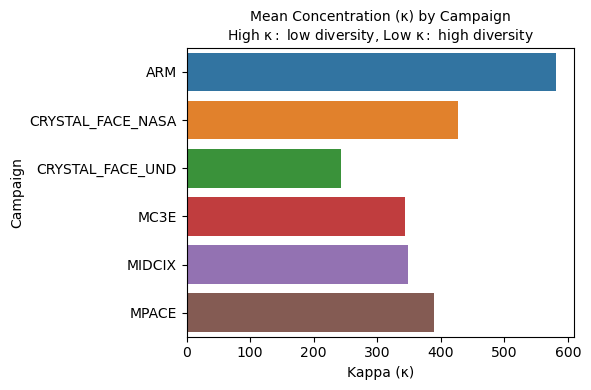

In [10]:
# Compute mean kappa per campaign
campaigns = df['Campaign'].unique()
kappas = []

for campaign in campaigns:
    df_camp = df[df['Campaign'] == campaign]
    if len(df_camp) == 0:
        kappas.append(np.nan)
        continue
    emb = df_camp[emb_cols].values
    kappa = estimate_kappa(emb)
    kappas.append(kappa)

# Create a summary DataFrame
summary_df = pd.DataFrame({'Campaign': campaigns, 'Kappa': kappas})

# Plot horizontal barplot
plt.figure(figsize=(6, 4))
sns.barplot(
    data=summary_df,
    y='Campaign',
    x='Kappa',
    palette='tab10',
    orient='h'
)
plt.xlabel('Kappa (κ)')
plt.ylabel('Campaign')
plt.title(
    'Mean Concentration (κ) by Campaign\n'
    r'$\mathregular{High\ \kappa:}$ low diversity, $\mathregular{Low\ \kappa:}$ high diversity',
    fontsize=10
)
plt.tight_layout()
savedir = '/home/jko/ssl-cpi-analysis/figs'
savepath = os.path.join(savedir, 'kappa-by-campaign.pdf')
plt.savefig(savepath, bbox_inches="tight") # save
plt.show()
